In [1]:
import pandas as pd
import numpy as np
import sns
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('./data/sign_mnist_train.csv')
test = pd.read_csv('./data/sign_mnist_test.csv')

In [3]:
train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27450,13,189,189,190,190,192,193,193,193,193,...,132,165,99,77,52,200,234,200,222,225
27451,23,151,154,157,158,160,161,163,164,166,...,198,198,198,198,198,196,195,195,195,194
27452,18,174,174,174,174,174,175,175,174,173,...,121,196,209,208,206,204,203,202,200,200
27453,17,177,181,184,185,187,189,190,191,191,...,119,56,27,58,102,79,47,64,87,93


In [4]:
train_label = train.iloc[:,:1]
test_label = test.iloc[:,:1]
train_set = train.iloc[:,1:]
test_set = test.iloc[:,1:]

In [5]:
train_set = tf.convert_to_tensor(train_set / 255.0)
test_set = tf.convert_to_tensor(test_set / 255.0)
train_label = tf.keras.utils.to_categorical(train_label)

In [6]:
train_set = tf.reshape(train_set, [-1, 28, 28,1])
test_set = tf.reshape(test_set, [-1, 28, 28,1])

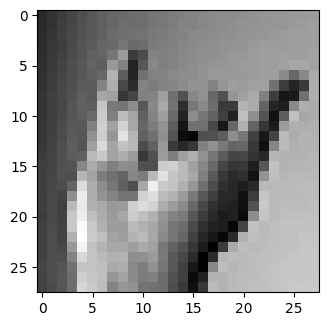

In [7]:
import random

def show_images(image):
    image = image.numpy().reshape(28,28)
    plt.figure(figsize=(8, 8))
    plt.subplot(1,2,2)
    plt.imshow(image, cmap='gray')

# for number_image in range(10):
#     show_images(train[number_image])

show_images(train_set[random.randrange(0,len(train_set)-1)])

In [8]:
train_label = tf.convert_to_tensor(train_label)
test_label = tf.convert_to_tensor(test_label)

In [9]:
train_ds = tf.data.Dataset.from_tensor_slices((train_set, train_label))
test_ds = tf.data.Dataset.from_tensor_slices((test_set, test_label))

In [10]:
# image_gen = tf.keras.preprocessing.image.ImageDataGenerator(
#     rescale=1./255.0,
#     rotation_range=40,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     zoom_range=0.2,
#     shear_range=0.2,
#     fill_mode='nearest'
# )

In [11]:
# train_ds = image_gen.flow(
#     x=train,
#     y=train_label,
#     batch_size=32
# )
# test_ds = image_gen.flow(
#     x=test,
#     y=test_label,
#     batch_size=32
# )

In [12]:
final_train_ds, final_val_ds = tf.keras.utils.split_dataset(train_ds, left_size=0.8)

In [13]:
final_train_ds = final_train_ds.shuffle(1000).batch(32)
final_val_ds = final_val_ds.batch(32)

In [14]:
aug = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

In [15]:
model = tf.keras.Sequential([])
model.add(tf.keras.Input(shape=(28,28,1)))
model.add(aug)
model.add(tf.keras.layers.Conv2D(32, (5,5), activation='relu',padding='same'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Conv2D(64, (5,5), activation='relu',padding='same'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
# model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(25, activation='softmax'))

In [16]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

In [17]:
model.compile(loss='categorical_crossentropy', optimizer=adam_optimizer, metrics=['accuracy'])

In [18]:
history = model.fit(final_train_ds, epochs=10, validation_data=final_val_ds)

Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.2399 - loss: 2.4236 - val_accuracy: 0.5270 - val_loss: 1.4249
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.5831 - loss: 1.2268 - val_accuracy: 0.7709 - val_loss: 0.7004
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.7502 - loss: 0.7317 - val_accuracy: 0.8414 - val_loss: 0.4524
Epoch 4/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.8225 - loss: 0.5147 - val_accuracy: 0.8822 - val_loss: 0.3345
Epoch 5/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.8681 - loss: 0.3807 - val_accuracy: 0.8865 - val_loss: 0.3287
Epoch 6/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.8982 - loss: 0.2987 - val_accuracy: 0.9421 - val_loss: 0.1737
Epoch 7/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.9167 - loss: 0.2437 - val_accuracy: 0.9654 - val_loss: 0.1057
Epoch 8/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9296 - loss: 0.2092 - 

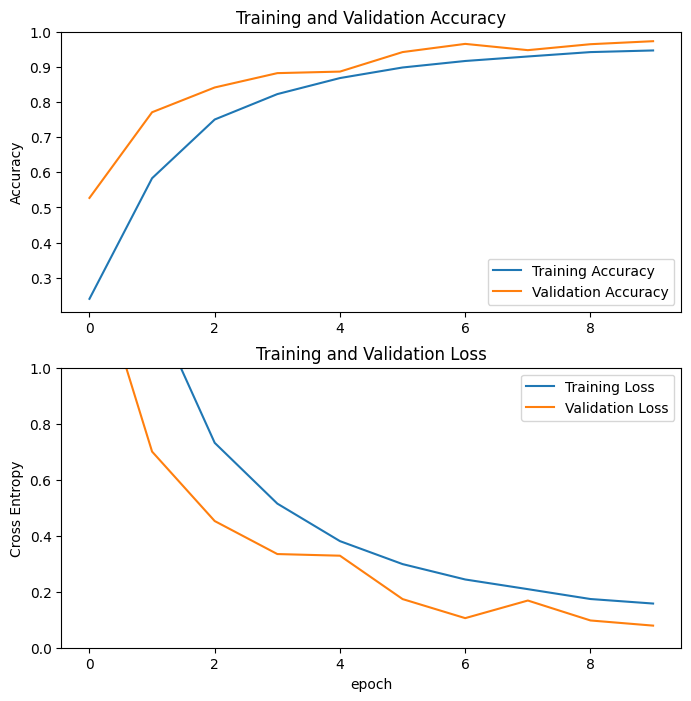

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [20]:
prediction = model.predict(test_set)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [21]:
predicted_labels = []
for i in range(0,len(test)):
    predicted_labels.append(np.argmax(prediction[i]))

In [22]:
predicted_labels = np.array(predicted_labels)
predicted_labels

array([ 6, 22, 10, ...,  2,  4,  2], shape=(7172,))

In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_label,predicted_labels)

<Axes: >

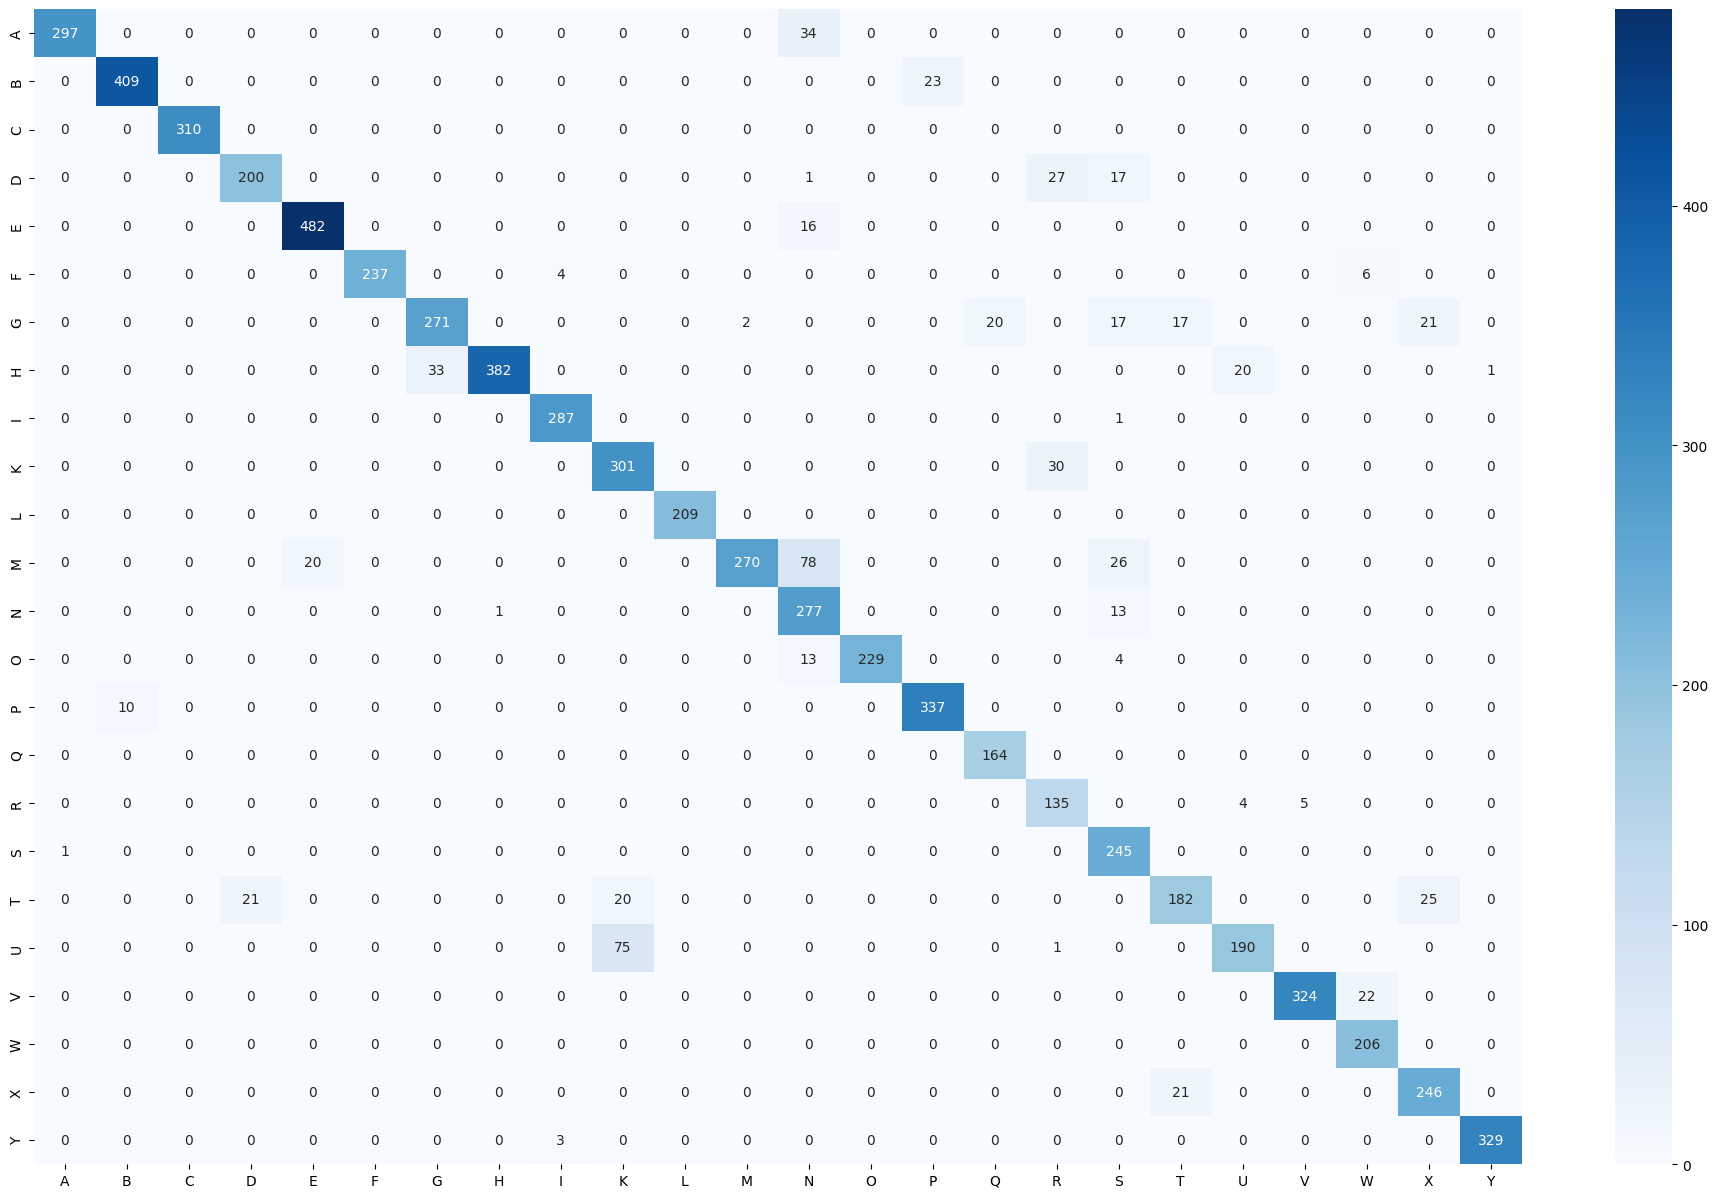

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
alphabet = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
df_cm = pd.DataFrame(cm, index = alphabet, columns = alphabet)
plt.figure(figsize = (24,15))
sns.heatmap(df_cm, annot=True,cmap='Blues',fmt='g')